# 01 — Exploring the fake job postings data

Goal: understand the data **before** building anything. No model is trained in this notebook.

Dataset: *Real or Fake Job Postings* (EMSCAD) — each row is one job posting, and the
`fraudulent` column is the **label**: `1` = scam, `0` = real. A label is the "right answer"
a model will later learn to predict.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# The notebook lives in notebooks/, so the data folder is one level up.
DATA_PATH = Path("..") / "data" / "fake_job_postings.csv"

# A DataFrame is pandas' name for a table: rows = postings, columns = fields.
df = pd.read_csv(DATA_PATH)
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**What this tells us:** Each row is one posting that mixes free text (title, description, company profile) with simple yes/no fields like `has_company_logo`. That means a scam detector can learn from two kinds of clues: the words a posting uses and basic facts about how it was filled in.

## 1. How big is the dataset?

In [2]:
rows, cols = df.shape
print(f"{rows:,} rows (job postings)")
print(f"{cols} columns (fields per posting)")
print()
print(list(df.columns))

17,880 rows (job postings)
18 columns (fields per posting)

['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


**What this tells us:** We have 17,880 postings with 18 fields each; one field (`fraudulent`) is the answer we want to predict, leaving 17 possible clues. That's enough examples to train a basic model, though it's small by machine-learning standards, so we should keep the model simple.

## 2. What % of postings are fraudulent?

In [3]:
# value_counts counts each label; normalize=True turns counts into fractions.
counts = df["fraudulent"].value_counts()
percents = df["fraudulent"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "percent": percents.round(2)})
summary.index = summary.index.map({0: "real", 1: "fake"})
summary

,count,percent
fraudulent,,
real,17014,95.16
fake,866,4.84


**What this tells us:** Only 4.84% of postings (866) are fake, so the data is **imbalanced**: one answer is far more common than the other. A lazy model that labelled *every* posting "real" would be 95% accurate yet catch zero scams, so later we'll judge the model by how many scams it actually catches, not by plain accuracy.

## 3. Which columns have the most missing values?

In [4]:
# isna() marks each empty cell True; mean() of True/False gives the fraction missing.
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
missing_pct.to_frame("% missing")

,% missing
salary_range,84.0
department,64.6
required_education,45.3
benefits,40.3
required_experience,39.4
function,36.1
industry,27.4
employment_type,19.4
company_profile,18.5
requirements,15.1


**What this tells us:** Missing data is the norm here — salary is blank in 84% of postings and department in 65% — so the model must cope with blanks instead of us throwing those rows away. Whether a field is left blank may itself be a clue (for example, a scammer skipping the company profile), which is worth checking in a later notebook.

## 4. Company logo and salary: fake vs. real

In [5]:
# has_company_logo is already 1/0. For salary we make a 1/0 column:
# 1 if the posting lists any salary_range, 0 if it is blank.
df["has_salary"] = df["salary_range"].notna().astype(int)

# For each group (real / fake), the mean of a 1/0 column = share of postings that have it.
by_label = df.groupby("fraudulent")[["has_company_logo", "has_salary"]].mean() * 100
by_label.index = by_label.index.map({0: "real", 1: "fake"})
by_label = by_label.round(1)
by_label

,has_company_logo,has_salary
fraudulent,,
real,81.9,15.5
fake,32.7,25.8


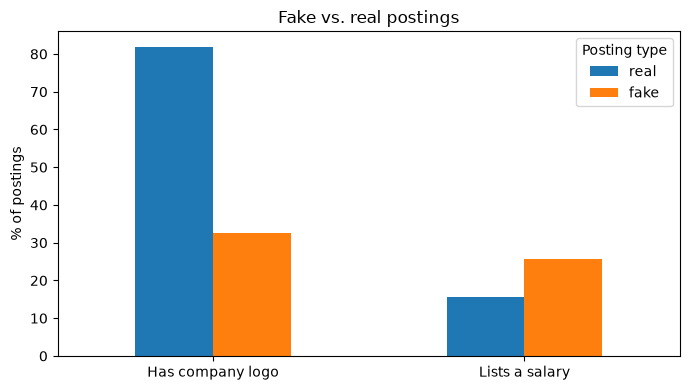

In [6]:
# Same numbers as a chart: side-by-side bars make the gap easy to see.
ax = by_label.T.plot(kind="bar", rot=0, figsize=(7, 4))
ax.set_ylabel("% of postings")
ax.set_xticklabels(["Has company logo", "Lists a salary"])
ax.set_title("Fake vs. real postings")
ax.legend(title="Posting type")
plt.tight_layout()
plt.show()

**What this tells us:** Only 32.7% of fake postings have a company logo versus 81.9% of real ones, making a missing logo one of the strongest simple warning signs so far. Surprisingly, fake postings list a salary *more* often (25.8% vs. 15.5%), possibly as bait — so neither signal is a verdict on its own, but both are useful clues for a model to combine.